Fuente: https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data
Shape: (19020, 11)
Clases: {0: 6688, 1: 12332}
Train: (14265, 10) Test: (4755, 10)


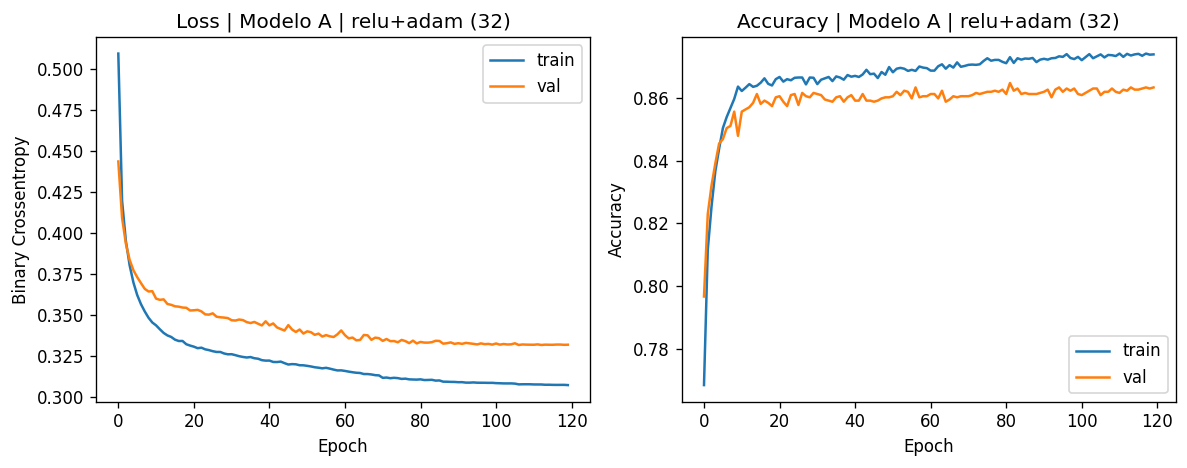

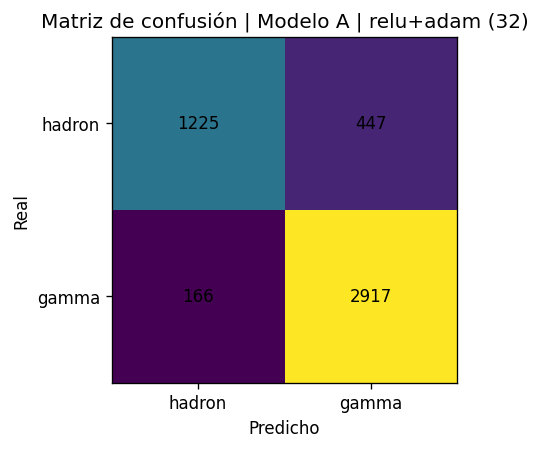

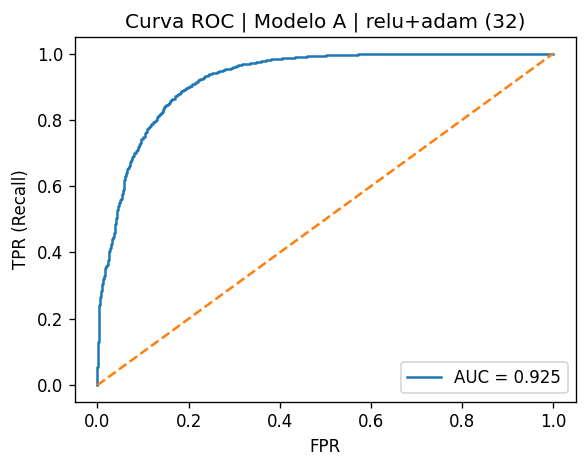


Reporte de clasificación | Modelo A | relu+adam (32)
               precision    recall  f1-score   support

      hadron       0.88      0.73      0.80      1672
       gamma       0.87      0.95      0.90      3083

    accuracy                           0.87      4755
   macro avg       0.87      0.84      0.85      4755
weighted avg       0.87      0.87      0.87      4755



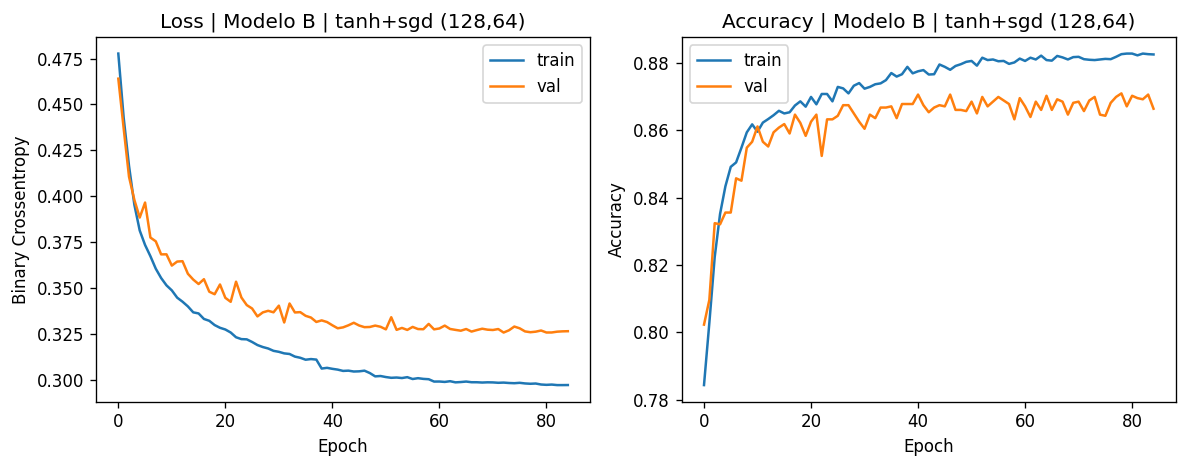

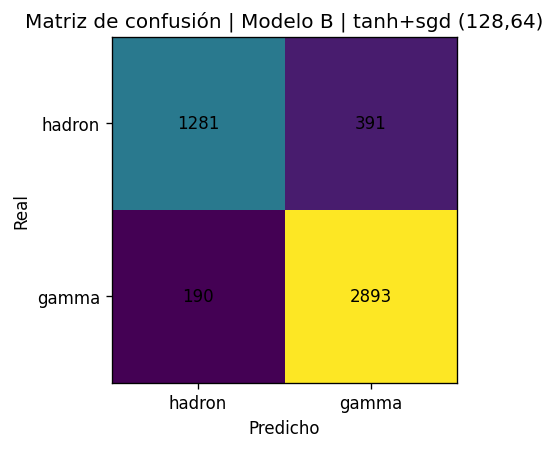

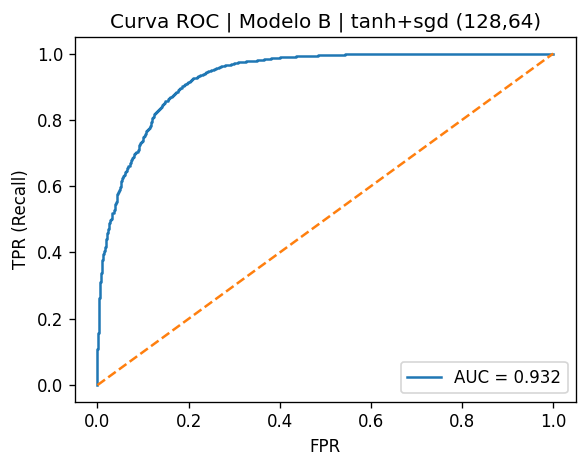


Reporte de clasificación | Modelo B | tanh+sgd (128,64)
               precision    recall  f1-score   support

      hadron       0.87      0.77      0.82      1672
       gamma       0.88      0.94      0.91      3083

    accuracy                           0.88      4755
   macro avg       0.88      0.85      0.86      4755
weighted avg       0.88      0.88      0.88      4755



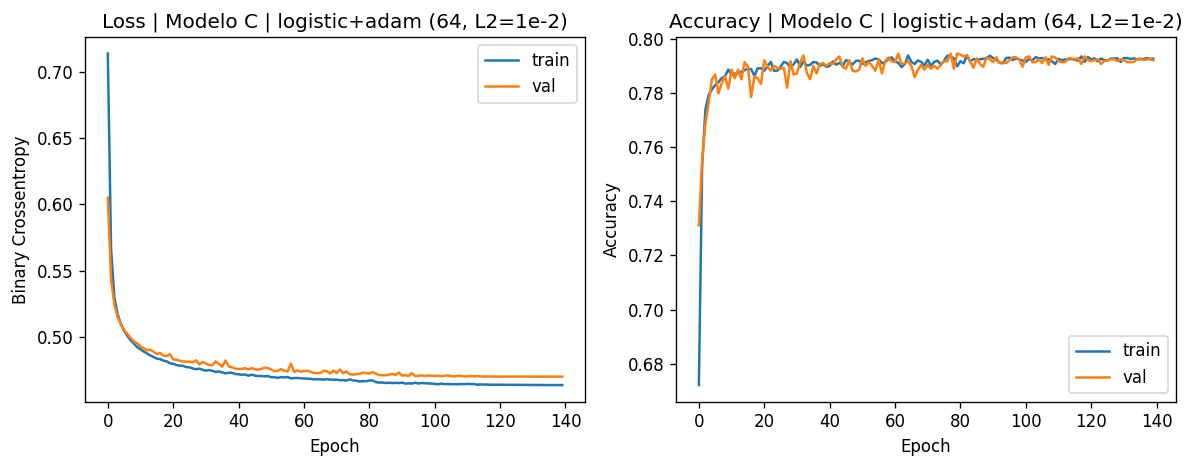

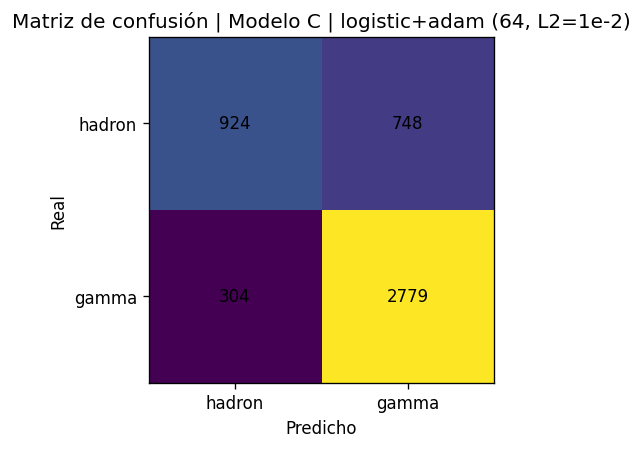

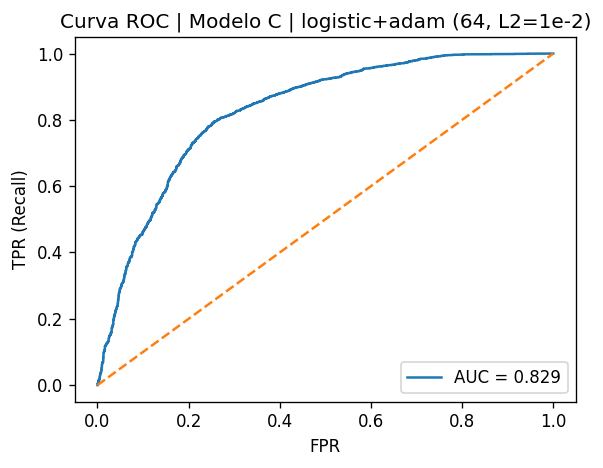


Reporte de clasificación | Modelo C | logistic+adam (64, L2=1e-2)
               precision    recall  f1-score   support

      hadron       0.75      0.55      0.64      1672
       gamma       0.79      0.90      0.84      3083

    accuracy                           0.78      4755
   macro avg       0.77      0.73      0.74      4755
weighted avg       0.78      0.78      0.77      4755


Tabla comparativa (ordenada por F1):
                                   modelo  accuracy  precision    recall  \
0            Modelo B | tanh+sgd (128,64)  0.877813   0.880938  0.938372   
1               Modelo A | relu+adam (32)  0.871083   0.867122  0.946156   
2  Modelo C | logistic+adam (64, L2=1e-2)  0.778759   0.787922  0.901395   

         f1       auc  
0  0.908748  0.932091  
1  0.904917  0.925093  
2  0.840847  0.828585  


In [ ]:
# ============================================================================
# MLP para Clasificación — MAGIC Gamma Telescope
# Copyright:
#   Jesus David Gelves Cajiao - 3000098650
#   Lina Maria Fernandez Garcia - 30000095421
# ============================================================================

# --------------------------
# Dependencias y utilidades
# --------------------------
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report,
    precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# ---------------------------------
# 1) Carga del dataset
# ---------------------------------
COLUMNS = [
    "fLength","fWidth","fSize","fConc","fConc1",
    "fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"
]

LOCAL_DIRS  = ["./magic_data", "/mnt/data/magic_data", "."]
LOCAL_FILES = ["magic04.data", "magic04.csv", "magic04.txt"]
URLS = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data",
]

def try_load_local():
    for d in LOCAL_DIRS:
        for f in LOCAL_FILES:
            p = os.path.join(d, f)
            if os.path.exists(p):
                df = pd.read_csv(p, header=None, names=COLUMNS)
                return df, p
    return None, None

def try_load_remote():
    last_err = None
    for url in URLS:
        try:
            df = pd.read_csv(url, header=None, names=COLUMNS)
            return df, url
        except Exception as e:
            last_err = e
    raise RuntimeError(f"No se pudo cargar MAGIC ni local ni remoto. Último error: {last_err!r}")

#Se prioriza el local, si no está, va al remoto
df, source = try_load_local()
if df is None:
    df, source = try_load_remote()

# Map etiquetas: h -> 0 (hadron), g -> 1 (gamma)
df["class"] = df["class"].astype(str).str.strip().map({"h":0, "g":1}).astype(int)

X = df.drop(columns=["class"]).values.astype(np.float32)
y = df["class"].values.astype(np.int32)
target_names = ["hadron","gamma"]

print("Fuente:", source)
print("Shape:", df.shape)
print("Clases:", df['class'].value_counts().sort_index().to_dict())

# -------------------------------------------------------
# 2) Conjunto de entrenamiento
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

# -------------------------
# 3) Construcción
# -------------------------
def build_model(hidden_layers, activation, optimizer, l2_alpha=0.0, input_dim=None):
    """MLP denso para binario con salida sigmoide."""
    model = Sequential()
    for i, units in enumerate(hidden_layers):
        if i == 0:
            model.add(Dense(units, activation=activation, input_shape=(input_dim,),
                            kernel_regularizer=l2(l2_alpha) if l2_alpha>0 else None))
        else:
            model.add(Dense(units, activation=activation,
                            kernel_regularizer=l2(l2_alpha) if l2_alpha>0 else None))
    # salida binaria
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_and_eval(model, X_train, y_train, X_test, y_test, name, epochs=100, batch_size=64):
    """Entrena con early stopping, grafica curvas y devuelve métricas y objetos útiles."""
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=0, min_lr=1e-5)
    ]
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks
    )

    # Curvas de aprendizaje
    fig, ax = plt.subplots(1,2, figsize=(10,4), dpi=120)
    ax[0].plot(history.history['loss'], label='train')
    ax[0].plot(history.history['val_loss'], label='val')
    ax[0].set_title(f'Loss | {name}')
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Binary Crossentropy'); ax[0].legend()

    ax[1].plot(history.history['accuracy'], label='train')
    ax[1].plot(history.history['val_accuracy'], label='val')
    ax[1].set_title(f'Accuracy | {name}')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy'); ax[1].legend()
    plt.tight_layout(); plt.show()

    # Predicciones
    y_proba = model.predict(X_test, verbose=0).ravel()
    y_pred  = (y_proba >= 0.5).astype(int)

    # Métricas globales
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_proba),
    }

    # Métricas por clase
    prec_c, rec_c, f1_c, supp_c = precision_recall_fscore_support(
        y_test, y_pred, labels=[0,1], zero_division=0
    )
    per_class = pd.DataFrame({
        "clase": target_names,
        "precision": prec_c,
        "recall": rec_c,
        "f1": f1_c,
        "soporte": supp_c
    })

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4,4), dpi=120)
    im = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f'Matriz de confusión | {name}')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(target_names); ax.set_yticklabels(target_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_ylabel("Real"); ax.set_xlabel("Predicho")
    plt.tight_layout(); plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    fig, ax = plt.subplots(figsize=(5,4), dpi=120)
    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0,1], [0,1], linestyle="--")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR (Recall)")
    ax.set_title(f"Curva ROC | {name}"); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()

    # Reporte sklearn
    print(f"\nReporte de clasificación | {name}\n",
          classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

    return metrics, per_class

# -------------------------------
# 4) Modelos
# -------------------------------
input_dim = X_train.shape[1]

# Modelo A — relu + adam (32)
model_A = build_model(
    hidden_layers=[32],
    activation='relu',
    optimizer=Adam(learning_rate=1e-3),
    l2_alpha=1e-4,
    input_dim=input_dim
)

# Modelo B — tanh + SGD (128,64) con momentum y LR 0.01
model_B = build_model(
    hidden_layers=[128, 64],
    activation='tanh',
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    l2_alpha=1e-4,
    input_dim=input_dim
)

# Modelo C — logistic (sigmoid en Keras) + adam (64) con L2 fuerte
model_C = build_model(
    hidden_layers=[64],
    activation='sigmoid',
    optimizer=Adam(learning_rate=1e-3),
    l2_alpha=1e-2,
    input_dim=input_dim
)

# -----------------------------------------
# 5) Entrenar, evaluar y comparar los tres
# -----------------------------------------
results = []
per_class_dict = {}

metrics_A, per_class_A = train_and_eval(model_A, X_train, y_train, X_test, y_test,
                                        name="Modelo A | relu+adam (32)", epochs=120, batch_size=64)
results.append({"modelo": "Modelo A | relu+adam (32)", **metrics_A})
per_class_dict["Modelo A | relu+adam (32)"] = per_class_A

metrics_B, per_class_B = train_and_eval(model_B, X_train, y_train, X_test, y_test,
                                        name="Modelo B | tanh+sgd (128,64)", epochs=160, batch_size=64)
results.append({"modelo": "Modelo B | tanh+sgd (128,64)", **metrics_B})
per_class_dict["Modelo B | tanh+sgd (128,64)"] = per_class_B

metrics_C, per_class_C = train_and_eval(model_C, X_train, y_train, X_test, y_test,
                                        name="Modelo C | logistic+adam (64, L2=1e-2)", epochs=140, batch_size=64)
results.append({"modelo": "Modelo C | logistic+adam (64, L2=1e-2)", **metrics_C})
per_class_dict["Modelo C | logistic+adam (64, L2=1e-2)"] = per_class_C

# -----------------------------
# 6) Tabla comparativa
# -----------------------------
results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
print("\nTabla comparativa (ordenada por F1):")
print(results_df)

